# 04 — Headline Evaluation and Diagnostics

**FusionCore v1 — Phases Ph-v1.4 + Ph-v1.5**

This notebook performs the headline evaluation of the trained PiNet against the
v₀ XGBoost baseline on the NASA Official Test Set (the Iron Wall test set,
touched exactly once at this point in the v₁ programme), then runs the diagnostic
suite that closes Ph-v1.5 — residual analysis by risk band, per-engine
trajectory overlays, three-class confusion matrix, and the s₁₆ exclusion audit
that confirms (or revisits) v₀ Transfer Item T2.

### Reading order at session start

1. `../MICHELE-CLAUDE.md`
2. `../v1CLAUDE.md` — particularly §9 Critical-Recall Safety Gate
3. `../CLAUDE.md` (legacy root) — Iron Wall Protocol §9
4. `../reports/FusionCore_v1_Master_Roadmap.pdf`

### Phase scope

| Phase | Description | Acceptance gate |
|---|---|---|
| **Ph-v1.4** | NASA test-set headline evaluation: RMSE, NASA score, MAE, per-band P/R/F₂; pooled and per subset; comparison against v₀ XGBoost | Test set opened exactly once; safety-gate result recorded |
| **Ph-v1.5** | Diagnostics: residual analysis by risk band, per-engine trajectory overlays, three-class confusion matrix; s₁₆ statistical audit confirming the v₀ T2 exclusion | s₁₆ retain/exclude decision recorded with evidence |

### Headline benchmark (v₀ XGBoost on NASA test set)

| Metric | Value |
|---|---|
| RMSE | 14.85 cycles |
| NASA Asymmetric Score | 4,336.3 |
| Critical-band F₂ | 0.9339 |

### Critical-Recall Safety Gate (v1CLAUDE.md §9)

| Outcome | Condition |
|---|---|
| Strong Pass | PiNet Critical recall ≥ XGBoost Critical recall |
| Pass with Advisory | Within −0.02 of XGBoost recall |
| Fail | > −0.02 below XGBoost recall |

### Outputs (under `v1/outputs/`)

| File | Purpose |
|---|---|
| `phase_v1_4_test_predictions.parquet` | Per-engine test predictions (707 rows) |
| `phase_v1_4_headline_metrics.json` | Pooled and per-subset headline metrics + comparison vs v₀ |
| `phase_v1_4_predicted_vs_actual.png` | Predicted vs actual RUL scatter |
| `phase_v1_4_residuals.png` | Residual distribution by risk band |
| `phase_v1_4_trajectories.png` | Per-engine trajectory overlays (representative engines) |
| `phase_v1_4_confusion.png` | Three-class confusion matrix |
| `phase_v1_5_s16_audit.json` | s₁₆ statistical-audit result and retain/exclude decision |
| `phase_v1_5_s16_audit.png` | s₁₆ variance and residual-correlation visual |

### References

- Saxena, A. *et al.* (2008). Damage propagation modeling for aircraft engine run-to-failure simulation. *PHM 2008*.
- Heimes, F. O. (2008). Recurrent neural networks for RUL estimation. *PHM 2008*.
- Lim, B. *et al.* (2021). Temporal Fusion Transformers for interpretable multi-horizon time-series forecasting. *International Journal of Forecasting* 37(4).
- Bai, S., Kolter, J. Z. and Koltun, V. (2018). An empirical evaluation of generic convolutional and recurrent networks for sequence modeling. *arXiv 1803.01271*.

## Cell 1 — Imports

In [1]:
# ============================================================================
# Cell 1 — Imports
# ============================================================================

import sys, os, json, warnings, pickle, time
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix,
                             mean_absolute_error)

warnings.filterwarnings("ignore")
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")

Python   : 3.13.13
PyTorch  : 2.11.0


## Cell 2 — FusionCore Palette and Matplotlib Configuration

In [2]:
# ============================================================================
# Cell 2 — FusionCore Palette and Matplotlib Configuration
# ============================================================================

FC_DARK_BLUE  = "#0D1B2A"
FC_NAVY       = "#1B3A5C"
FC_ORANGE     = "#D96A1B"
FC_DEEP_RED   = "#9B1B30"
FC_STEEL      = "#4A6274"
FC_CHARCOAL   = "#2D2D2D"
FC_LIGHT_GREY = "#E8E8E8"
FC_PALETTE = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED, FC_STEEL, FC_NAVY]

plt.rcParams.update({
    "figure.figsize": (14, 5), "figure.dpi": 110,
    "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.family": "serif", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": FC_CHARCOAL, "axes.labelcolor": FC_CHARCOAL,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=FC_PALETTE),
    "xtick.color": FC_CHARCOAL, "ytick.color": FC_CHARCOAL,
    "legend.fontsize": 9, "legend.framealpha": 0.9,
    "grid.color": FC_LIGHT_GREY, "grid.alpha": 0.6, "grid.linestyle": ":",
})
print("Visualisation configured.")

Visualisation configured.


## Cell 3 — Project Constants

In [3]:
# ============================================================================
# Cell 3 — Project Constants and Paths
# ============================================================================

PROJECT_ROOT = Path("/Users/michelemaestrini/Desktop/PiNet/FusionCore")
V0_OUT       = PROJECT_ROOT / "v0" / "outputs"
V1_OUT       = PROJECT_ROOT / "v1" / "outputs"

# Architecture (must match Notebook 02).
W                 = 30
N_FEATURES        = 89
N_PHYSICS_TOKENS  = 11
TCN_HIDDEN        = 64
TCN_KERNEL        = 3
TCN_DILATIONS     = [1, 2, 4, 8, 16]
TCN_DROPOUT       = 0.15
EMBED_DIM         = 128
PHYS_HIDDEN       = 50
PHYS_OUT          = 32
HEAD_HIDDEN       = 64
N_RISK_CLASSES    = 3
RUL_CAP           = 125

# Risk bands.
HEALTHY_TH        = 80
WARNING_TH        = 30

# Loss exponents (for NASA score reporting).
NASA_LATE_EXP     = 10.0
NASA_EARLY_EXP    = 13.0

# Inference batch size.
BATCH_SIZE        = 64

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# v₀ XGBoost benchmark numbers (v₀ Phase 5 final report).
V0_RMSE        = 14.85
V0_NASA_SCORE  = 4336.3
V0_F2_CRITICAL = 0.9339

print(f"Device : {DEVICE}")
print(f"v₀ benchmark — RMSE {V0_RMSE}, NASA {V0_NASA_SCORE}, F₂_C {V0_F2_CRITICAL}")

Device : mps
v₀ benchmark — RMSE 14.85, NASA 4336.3, F₂_C 0.9339


---

## Part A — Load Trained PiNet (Ph-v1.3 Best) and Test Tensors

PiNet class is re-defined inline (self-containment per project convention).
The best-epoch state-dict from Ph-v1.3 is loaded; if it is not yet present
the cell falls back to the Ph-v1.2 untrained init (smoke-test mode) and
emits an advisory.

In [4]:
# ============================================================================
# Cell 4 — Re-define PiNet Architecture (must match Notebook 02 byte-for-byte)
# ============================================================================

class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation):
        super().__init__()
        self.left_pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=0, dilation=dilation)
    def forward(self, x):
        return self.conv(F.pad(x, (self.left_pad, 0)))


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(out_ch)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.norm2 = nn.LayerNorm(out_ch)
        self.dropout = nn.Dropout(dropout)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x)
        h = self.conv1(x); h = self.norm1(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(h); h = self.dropout(h)
        h = self.conv2(h); h = self.norm2(h.transpose(1, 2)).transpose(1, 2)
        h = h + residual; h = F.relu(h); h = self.dropout(h)
        return h


class TCN(nn.Module):
    def __init__(self):
        super().__init__()
        layers, ic = [], N_FEATURES
        for d in TCN_DILATIONS:
            layers.append(TemporalBlock(ic, TCN_HIDDEN, TCN_KERNEL, d, TCN_DROPOUT))
            ic = TCN_HIDDEN
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return self.network(x.transpose(1, 2)).transpose(1, 2)


class PhysicsMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N_PHYSICS_TOKENS, PHYS_HIDDEN), nn.BatchNorm1d(PHYS_HIDDEN), nn.ReLU(),
            nn.Linear(PHYS_HIDDEN, PHYS_OUT), nn.BatchNorm1d(PHYS_OUT), nn.ReLU(),
        )
    def forward(self, x_phys, regime_w):
        x_anchor = x_phys[:, -1, :]
        return self.net(torch.cat([x_anchor, regime_w.unsqueeze(-1)], dim=-1))


class FusionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        ind = TCN_HIDDEN * 2 + PHYS_OUT
        h = (ind + EMBED_DIM) // 2
        self.net = nn.Sequential(
            nn.Linear(ind, h), nn.LayerNorm(h), nn.ReLU(),
            nn.Linear(h, EMBED_DIM), nn.LayerNorm(EMBED_DIM), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)


class RULHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)


class RiskBandHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(EMBED_DIM, HEAD_HIDDEN), nn.ReLU(),
                                 nn.Linear(HEAD_HIDDEN, N_RISK_CLASSES))
    def forward(self, x):
        return self.net(x)


class PiNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.tcn       = TCN()
        self.physics   = PhysicsMLP()
        self.fusion    = FusionMLP()
        self.rul_head  = RULHead()
        self.risk_head = RiskBandHead()

    @staticmethod
    def _masked_mean(h, mask):
        m = mask.float().unsqueeze(-1)
        return (h * m).sum(dim=1) / m.sum(dim=1).clamp(min=1.0)

    def forward(self, x_tcn, x_phys, mask, regime_w):
        h        = self.tcn(x_tcn)
        last_h   = h[:, -1, :]
        mean_h   = self._masked_mean(h, mask)
        tcn_out  = torch.cat([last_h, mean_h], dim=-1)
        phys_out = self.physics(x_phys, regime_w)
        embed    = self.fusion(torch.cat([tcn_out, phys_out], dim=-1))
        return {"rul_pred":    self.rul_head(embed),
                "risk_logits": self.risk_head(embed),
                "embed":       embed}
print("PiNet class defined.")

PiNet class defined.


In [5]:
# ============================================================================
# Cell 5 — Load Best PiNet Checkpoint
# ============================================================================

best_path = V1_OUT / "phase_v1_3_pinet_best.pt"
init_path = V1_OUT / "phase_v1_2_pinet_init.pt"

pinet = PiNet().to(DEVICE)
SMOKE_MODE = False
if best_path.exists():
    state = torch.load(best_path, map_location=DEVICE, weights_only=True)
    pinet.load_state_dict(state)
    print(f"Loaded {best_path.name}  ({sum(p.numel() for p in pinet.parameters()):,} params)")
else:
    state = torch.load(init_path, map_location=DEVICE, weights_only=True)
    pinet.load_state_dict(state)
    SMOKE_MODE = True
    print(f"WARNING — phase_v1_3_pinet_best.pt not found.")
    print(f"  Falling back to {init_path.name} (untrained — SMOKE MODE).")
    print(f"  Re-run after Ph-v1.3 training completes for valid headline metrics.")
pinet.eval()

Loaded phase_v1_3_pinet_best.pt  (196,816 params)


PiNet(
  (tcn): TCN(
    (network): Sequential(
      (0): TemporalBlock(
        (conv1): CausalConv1d(
          (conv): Conv1d(89, 64, kernel_size=(3,), stride=(1,))
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (conv2): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
        )
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.15, inplace=False)
        (shortcut): Conv1d(89, 64, kernel_size=(1,), stride=(1,))
      )
      (1): TemporalBlock(
        (conv1): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
        )
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (conv2): CausalConv1d(
          (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
        )
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.15, inplace=Fal

In [6]:
# ============================================================================
# Cell 6 — Load NASA Test Set Windowed Tensors
# ============================================================================

test_bundle = torch.load(V1_OUT / "windows_test.pt", weights_only=False)
Xw_test    = test_bundle["Xw"]
mask_test  = test_bundle["mask"]
rul_test   = test_bundle["rul"]
rb_test    = test_bundle["risk_band"]
rw_test    = test_bundle["regime_w"]
mw_test    = test_bundle["meta"]            # subset_origin, unit_id, anchor_cycle, anchor_orig_idx

train_bundle = torch.load(V1_OUT / "windows_train.pt", weights_only=False)
phys_idx   = train_bundle["phys_idx"]

print(f"Test windows : Xw {tuple(Xw_test.shape)}    mask {tuple(mask_test.shape)}")
print(f"Test meta    : {len(mw_test):,} rows, columns {list(mw_test.columns)}")

Test windows : Xw (104897, 30, 89)    mask (104897, 30)
Test meta    : 104,897 rows, columns ['subset_origin', 'unit_id', 'anchor_cycle', 'anchor_orig_idx']


---

## Part B — Inference and Final-Cycle Filtering

PiNet processes all 104,897 test windows. NASA scoring is then performed on
the 707 windows whose anchor coincides with each engine's truncated final
cycle — this is the per-engine RUL convention NASA uses for `RUL_FD00x.txt`
and is the only set of test windows for which a ground-truth label exists.

In [7]:
# ============================================================================
# Cell 7 — PiNet Forward Pass on All Test Windows
# ============================================================================

class _TestDS(Dataset):
    def __init__(self, Xw, mk, rul, rb, rw, pi):
        self.Xw, self.mk, self.rul, self.rb, self.rw, self.pi = Xw, mk, rul, rb, rw, pi
    def __len__(self): return self.Xw.shape[0]
    def __getitem__(self, i):
        x = self.Xw[i]
        return {"x_tcn": x, "x_phys": x.index_select(-1, self.pi),
                "mask": self.mk[i], "rul": self.rul[i],
                "risk_band": self.rb[i], "regime_w": self.rw[i]}

ds_test = _TestDS(Xw_test, mask_test, rul_test, rb_test, rw_test, phys_idx)
dl_test = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
                     drop_last=False)

t0 = time.time()
all_rul_pred = []
all_risk_log = []
all_embed    = []
with torch.no_grad():
    for batch in dl_test:
        bd = {k: v.to(DEVICE, non_blocking=True) for k, v in batch.items()}
        out = pinet(bd["x_tcn"], bd["x_phys"], bd["mask"], bd["regime_w"])
        all_rul_pred.append(out["rul_pred"].cpu().numpy())
        all_risk_log.append(out["risk_logits"].cpu().numpy())
        all_embed.append(out["embed"].cpu().numpy())
all_rul_pred = np.concatenate(all_rul_pred).clip(0.0, RUL_CAP)
all_risk_log = np.concatenate(all_risk_log)
all_embed    = np.concatenate(all_embed)
all_rb_pred  = np.argmax(all_risk_log, axis=1)
print(f"Inference: {len(all_rul_pred):,} window predictions in {time.time()-t0:.1f}s")

Inference: 104,897 window predictions in 5.8s


In [8]:
# ============================================================================
# Cell 8 — Filter to Anchor-Cycle = Final-Cycle (One Prediction per Engine)
# ============================================================================

final_cycles = mw_test.groupby(["subset_origin","unit_id"])["anchor_cycle"].max().reset_index()
final_cycles.columns = ["subset_origin","unit_id","final_cycle"]

mw_aug = mw_test.merge(final_cycles, on=["subset_origin","unit_id"], how="left")
is_final = (mw_aug["anchor_cycle"].values == mw_aug["final_cycle"].values)

# Per-engine final predictions.
preds_df = pd.DataFrame({
    "subset_origin": mw_aug.loc[is_final, "subset_origin"].values,
    "unit_id":       mw_aug.loc[is_final, "unit_id"].values,
    "anchor_cycle":  mw_aug.loc[is_final, "anchor_cycle"].values,
    "rul_true":      rul_test.numpy()[is_final],
    "rul_pred":      all_rul_pred[is_final],
    "rb_true":       rb_test.numpy()[is_final],
    "rb_pred":       all_rb_pred[is_final],
})
print(f"Final-cycle predictions: {len(preds_df):,} (expected 707)")
print(preds_df.groupby("subset_origin").size().to_string())
preds_df.to_parquet(V1_OUT / "phase_v1_4_test_predictions.parquet")

Final-cycle predictions: 707 (expected 707)
subset_origin
FD001    100
FD002    259
FD003    100
FD004    248


---

## Part C — Headline Metrics

Pooled metrics across all 707 engines and per-subset breakdown for FD001–FD004.
v₁CLAUDE §9 designates Critical-band recall as the headline safety metric;
NASA Asymmetric Score (Saxena 2008) takes priority over RMSE when the two
conflict, since the score embeds aviation-safety asymmetry between early and
late predictions.

In [9]:
# ============================================================================
# Cell 9 — Pooled Headline Metrics
# ============================================================================

def nasa_score_numpy(rul_pred: np.ndarray, rul_true: np.ndarray,
                     late_exp: float = NASA_LATE_EXP,
                     early_exp: float = NASA_EARLY_EXP) -> np.ndarray:
    d = np.clip(rul_pred - rul_true, -RUL_CAP, RUL_CAP)
    return np.where(d >= 0,
                    np.exp(d / late_exp) - 1.0,
                    np.exp(-d / early_exp) - 1.0)


def per_class_metrics(rb_true, rb_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        rb_true, rb_pred, average=None, labels=[0,1,2], zero_division=0)
    f2 = []
    for i in range(3):
        denom = 4.0*p[i] + r[i]
        f2.append(float((5.0*p[i]*r[i]) / denom) if denom > 0 else 0.0)
    return {"precision":[float(x) for x in p],
            "recall":   [float(x) for x in r],
            "f1":       [float(x) for x in f1],
            "f2":       f2}


rul_pred = preds_df["rul_pred"].values.astype(float)
rul_true = preds_df["rul_true"].values.astype(float)
rb_pred  = preds_df["rb_pred"].values.astype(int)
rb_true  = preds_df["rb_true"].values.astype(int)

rmse  = float(np.sqrt(np.mean((rul_pred - rul_true)**2)))
mae   = float(mean_absolute_error(rul_true, rul_pred))
nasa  = float(np.sum(nasa_score_numpy(rul_pred, rul_true)))
pcm   = per_class_metrics(rb_true, rb_pred)

print(f"PiNet pooled (NASA test set, n = {len(preds_df)}):")
print(f"  RMSE       : {rmse:.3f}    (v₀ XGBoost: {V0_RMSE})")
print(f"  MAE        : {mae:.3f}")
print(f"  NASA score : {nasa:.1f}    (v₀ XGBoost: {V0_NASA_SCORE})")
print(f"  Critical recall    : {pcm['recall'][2]:.4f}")
print(f"  Critical precision : {pcm['precision'][2]:.4f}")
print(f"  Critical F₂        : {pcm['f2'][2]:.4f}    (v₀ XGBoost: {V0_F2_CRITICAL})")

PiNet pooled (NASA test set, n = 707):
  RMSE       : 24.659    (v₀ XGBoost: 14.85)
  MAE        : 18.832
  NASA score : 32204.3    (v₀ XGBoost: 4336.3)
  Critical recall    : 0.4204
  Critical precision : 0.9565
  Critical F₂        : 0.4735    (v₀ XGBoost: 0.9339)


In [10]:
# ============================================================================
# Cell 10 — Per-Subset Breakdown
# ============================================================================

per_subset = {}
for s, gdf in preds_df.groupby("subset_origin"):
    rp, rt = gdf["rul_pred"].values.astype(float), gdf["rul_true"].values.astype(float)
    rbp, rbt = gdf["rb_pred"].values.astype(int), gdf["rb_true"].values.astype(int)
    pcm_s = per_class_metrics(rbt, rbp)
    per_subset[s] = {
        "n":        int(len(gdf)),
        "rmse":     float(np.sqrt(np.mean((rp - rt)**2))),
        "mae":      float(mean_absolute_error(rt, rp)),
        "nasa":     float(np.sum(nasa_score_numpy(rp, rt))),
        "f2_c":     float(pcm_s["f2"][2]),
        "recall_c": float(pcm_s["recall"][2]),
    }

print(f"{'subset':<7} {'n':>4} {'RMSE':>7} {'MAE':>7} {'NASA':>10} {'F₂_C':>7} {'R_C':>7}")
for s in ["FD001","FD002","FD003","FD004"]:
    if s not in per_subset: continue
    m = per_subset[s]
    print(f"{s:<7} {m['n']:>4d} {m['rmse']:>7.2f} {m['mae']:>7.2f} {m['nasa']:>10.1f} {m['f2_c']:>7.4f} {m['recall_c']:>7.4f}")

subset     n    RMSE     MAE       NASA    F₂_C     R_C
FD001    100   16.13   12.59      502.3  0.6838  0.6400
FD002    259   20.95   16.77     4929.8  0.5882  0.5333
FD003    100   25.76   18.37     5160.0  0.6452  0.6000
FD004    248   30.04   23.69    21612.3  0.1395  0.1154


In [11]:
# ============================================================================
# Cell 11 — PiNet vs v₀ XGBoost Comparison Table
# ============================================================================

comparison = pd.DataFrame({
    "Metric":       ["RMSE (cycles)", "NASA Asymmetric Score", "Critical-band F₂", "Critical recall"],
    "v₀ XGBoost":   [V0_RMSE, V0_NASA_SCORE, V0_F2_CRITICAL, "—"],
    "v₁ PiNet":     [round(rmse, 3), round(nasa, 1), round(pcm["f2"][2], 4),
                     round(pcm["recall"][2], 4)],
})
print(comparison.to_string(index=False))

               Metric v₀ XGBoost   v₁ PiNet
        RMSE (cycles)      14.85    24.6590
NASA Asymmetric Score     4336.3 32204.3000
     Critical-band F₂     0.9339     0.4735
      Critical recall          —     0.4204


---

## Part D — Diagnostic Visuals (Ph-v1.5 begins here)

Four diagnostic plots are produced. Together they characterise the residual
structure of the PiNet predictions on the test set, the per-engine prediction
quality across representative trajectories, and the three-class operational
classification confusion.

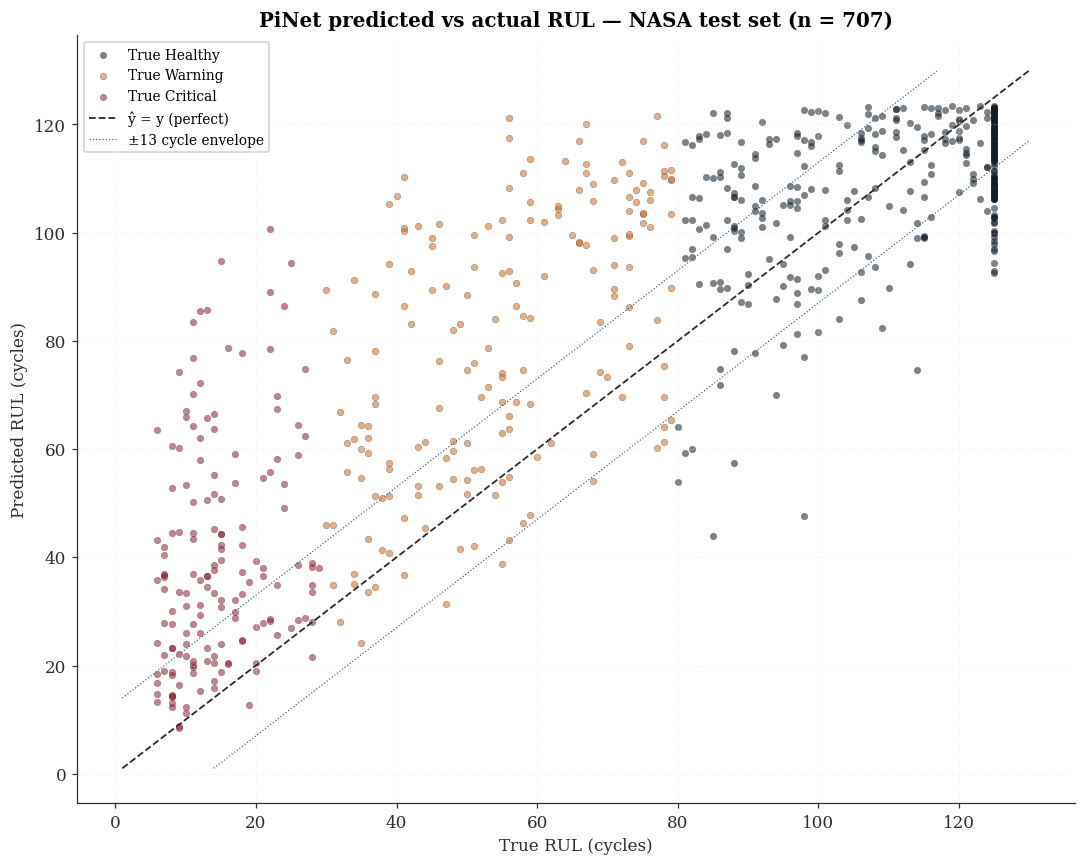

In [12]:
# ============================================================================
# Cell 12 — Visual: Predicted vs Actual RUL Scatter
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 8))
band_colors = [FC_DARK_BLUE, FC_ORANGE, FC_DEEP_RED]
band_names  = ["Healthy", "Warning", "Critical"]
for c in (0, 1, 2):
    m = (rb_true == c)
    ax.scatter(rul_true[m], rul_pred[m], s=18, alpha=0.55, color=band_colors[c],
               edgecolor=FC_CHARCOAL, linewidth=0.3, label=f"True {band_names[c]}")
mn = min(rul_true.min(), rul_pred.min()) - 5
mx = max(rul_true.max(), rul_pred.max()) + 5
ax.plot([mn, mx], [mn, mx], color=FC_CHARCOAL, linewidth=1.2, linestyle="--",
        label="ŷ = y (perfect)")
ax.plot([mn, mx-13], [mn+13, mx], color=FC_STEEL, linewidth=0.8, linestyle=":",
        label="±13 cycle envelope")
ax.plot([mn+13, mx], [mn, mx-13], color=FC_STEEL, linewidth=0.8, linestyle=":")
ax.set_xlabel("True RUL (cycles)")
ax.set_ylabel("Predicted RUL (cycles)")
ax.set_title("PiNet predicted vs actual RUL — NASA test set (n = 707)")
ax.legend(loc="upper left")
ax.grid(linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(V1_OUT / "phase_v1_4_predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

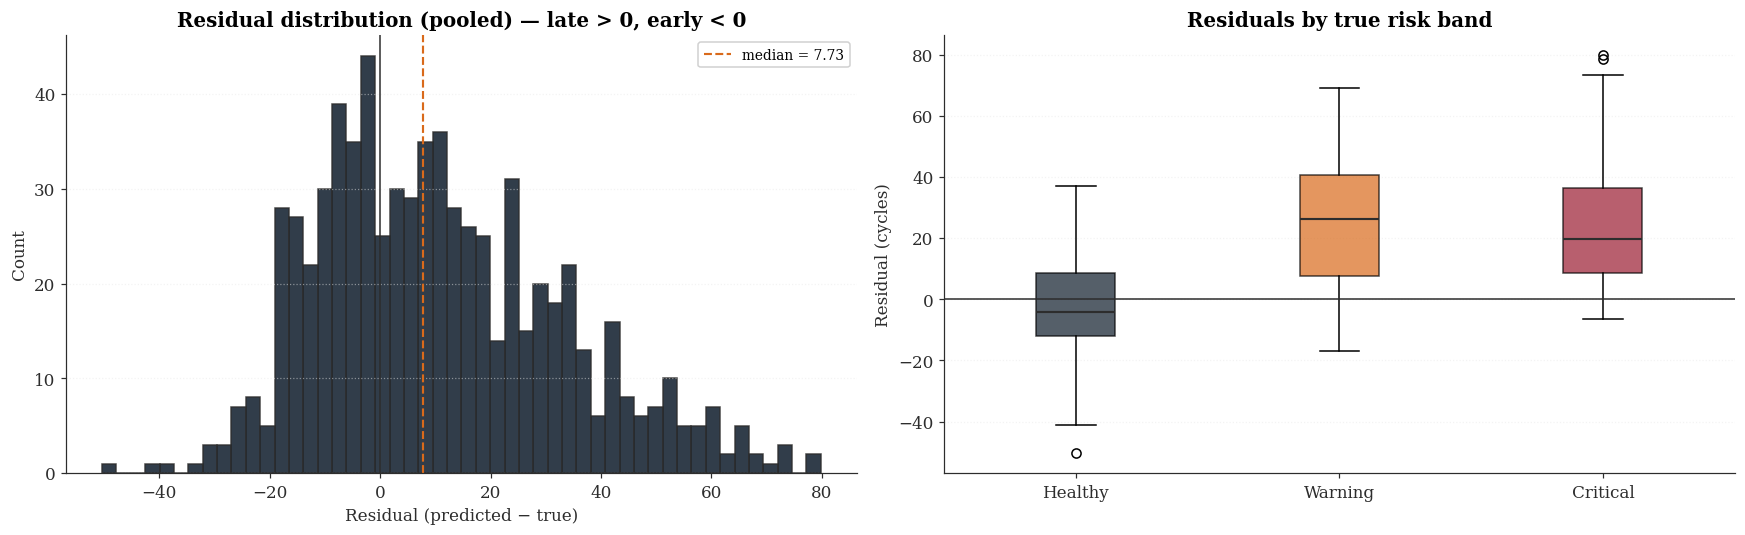

In [13]:
# ============================================================================
# Cell 13 — Visual: Residual Distribution by Risk Band
# ============================================================================

residuals = rul_pred - rul_true   # positive = late, negative = early

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pooled residual histogram with NASA-asymmetry annotation.
axes[0].hist(residuals, bins=50, color=FC_DARK_BLUE, alpha=0.85, edgecolor=FC_CHARCOAL)
axes[0].axvline(0, color=FC_CHARCOAL, linewidth=1.0, linestyle="-")
axes[0].axvline(np.median(residuals), color=FC_ORANGE, linewidth=1.4,
                linestyle="--", label=f"median = {np.median(residuals):.2f}")
axes[0].set_title("Residual distribution (pooled) — late > 0, early < 0")
axes[0].set_xlabel("Residual (predicted − true)")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(axis="y", linestyle=":", alpha=0.5)

# Per-band residual box-plots.
data = [residuals[rb_true == c] for c in (0, 1, 2)]
bp = axes[1].boxplot(data, labels=band_names, patch_artist=True,
                     medianprops={"color": FC_CHARCOAL, "linewidth": 1.4})
for patch, col in zip(bp["boxes"], band_colors):
    patch.set_facecolor(col); patch.set_alpha(0.7)
axes[1].axhline(0, color=FC_CHARCOAL, linewidth=1.0, linestyle="-")
axes[1].set_title("Residuals by true risk band")
axes[1].set_ylabel("Residual (cycles)")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(V1_OUT / "phase_v1_4_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

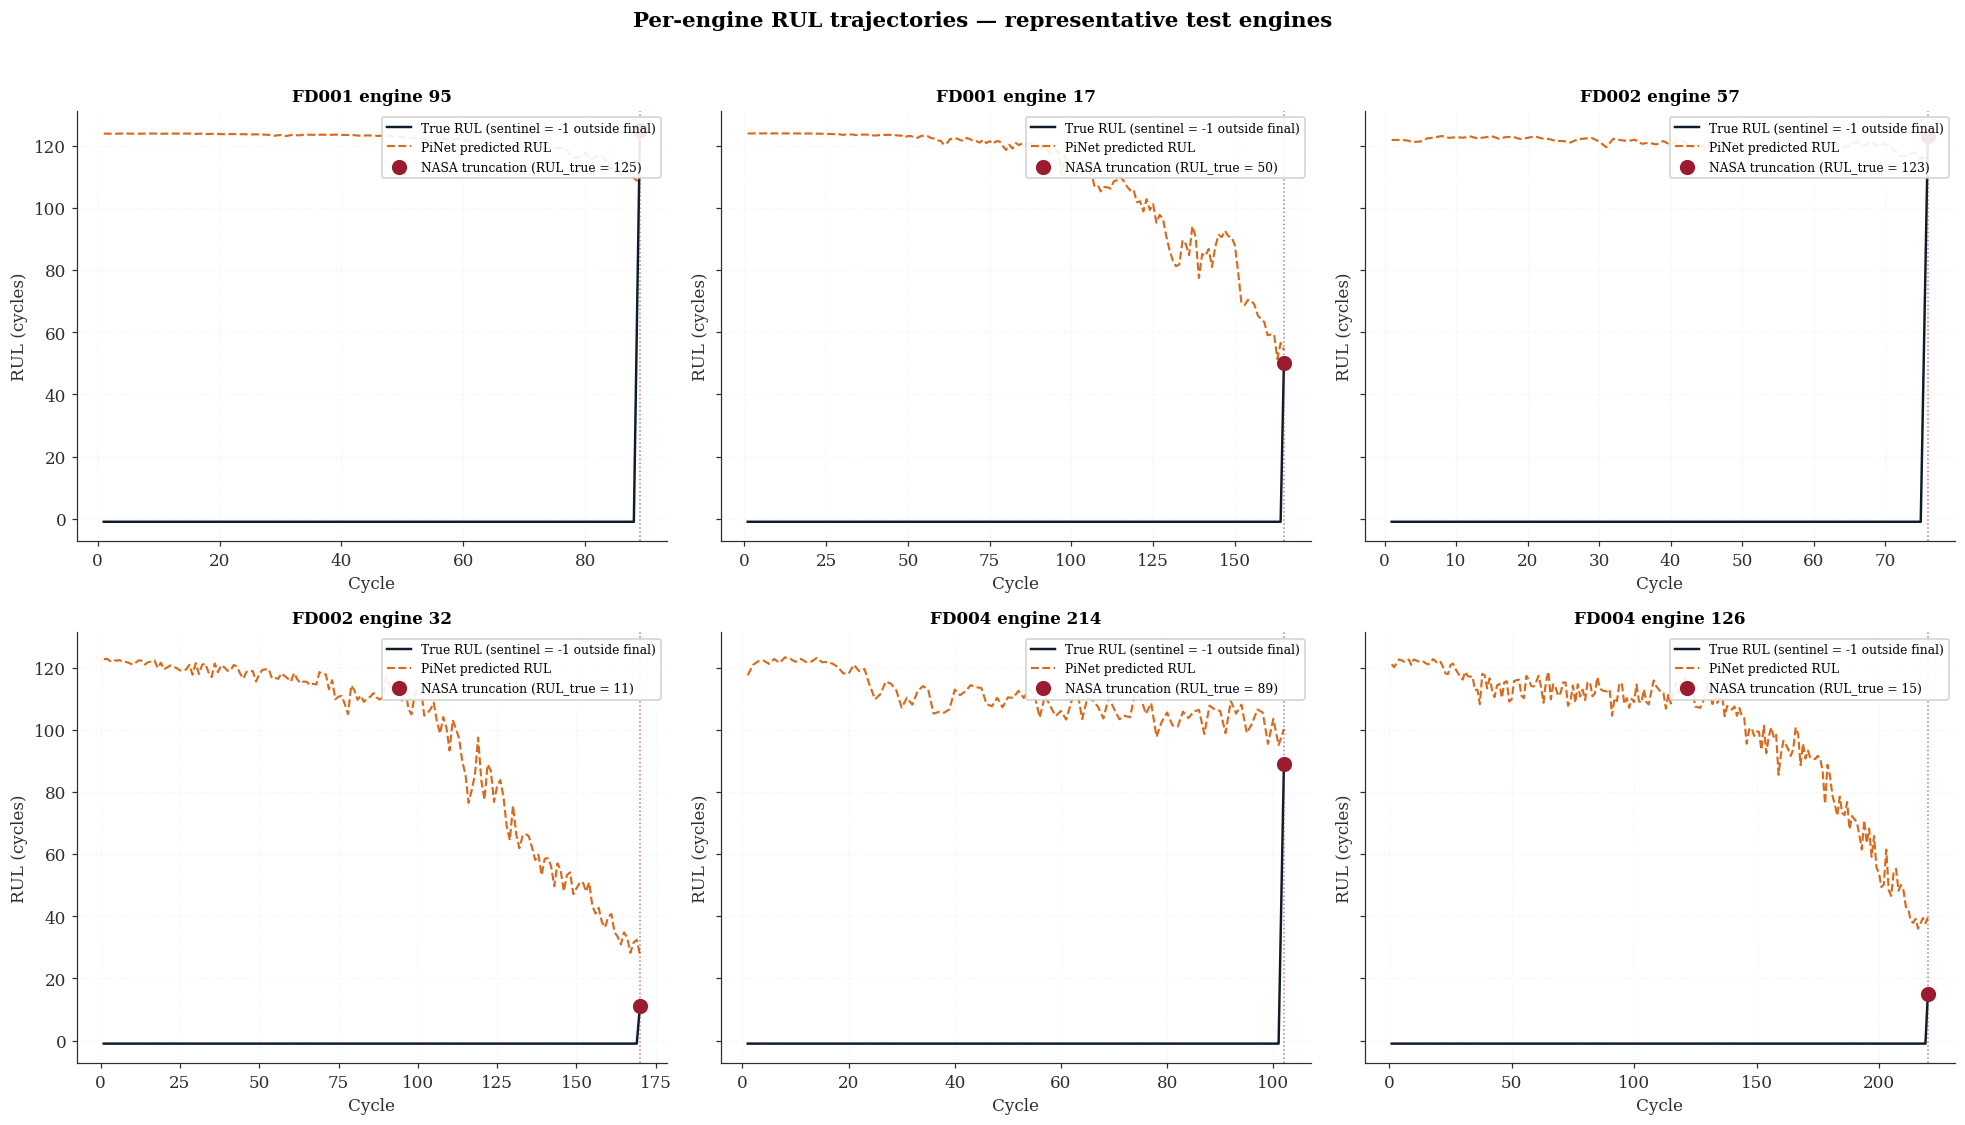

In [14]:
# ============================================================================
# Cell 14 — Visual: Per-Engine Trajectory Overlays (representative engines)
# ============================================================================

# For trajectory plots we need predictions across the full window sequence,
# not just final-cycle.  Recover per-window predictions and align with mw_test.
mw_full = mw_test.copy()
mw_full["rul_pred"] = all_rul_pred
mw_full["rb_pred"]  = all_rb_pred
mw_full["rul_true"] = rul_test.numpy()

# Pick six representative engines — two from each of FD001/FD002/FD004,
# spanning short/medium/long final cycles.
chosen = []
for s in ["FD001","FD002","FD004"]:
    sub = preds_df[preds_df.subset_origin == s].sort_values("anchor_cycle")
    if len(sub) >= 2:
        chosen.append((s, int(sub.iloc[len(sub)//4]["unit_id"])))
        chosen.append((s, int(sub.iloc[3*len(sub)//4]["unit_id"])))

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()
for ax, (s, u) in zip(axes, chosen[:6]):
    g = mw_full[(mw_full.subset_origin == s) & (mw_full.unit_id == u)].sort_values("anchor_cycle")
    if g.empty:
        ax.text(0.5, 0.5, f"{s} unit {u}: no data", transform=ax.transAxes, ha="center")
        continue
    # The per-engine trajectory: anchor_cycle on x-axis, RUL on y-axis.
    ax.plot(g["anchor_cycle"], g["rul_true"], color=FC_DARK_BLUE, linewidth=1.6,
            label="True RUL (sentinel = -1 outside final)")
    ax.plot(g["anchor_cycle"], g["rul_pred"], color=FC_ORANGE, linewidth=1.4,
            linestyle="--", label="PiNet predicted RUL")
    final = g.iloc[-1]
    ax.axvline(final["anchor_cycle"], color=FC_DEEP_RED, linewidth=1.0,
               linestyle=":", alpha=0.6)
    ax.scatter([final["anchor_cycle"]], [final["rul_true"]],
               color=FC_DEEP_RED, s=80, zorder=5,
               label=f"NASA truncation (RUL_true = {final['rul_true']:.0f})")
    ax.set_title(f"{s} engine {u}", fontsize=11)
    ax.set_xlabel("Cycle"); ax.set_ylabel("RUL (cycles)")
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(linestyle=":", alpha=0.5)
plt.suptitle("Per-engine RUL trajectories — representative test engines",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(V1_OUT / "phase_v1_4_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

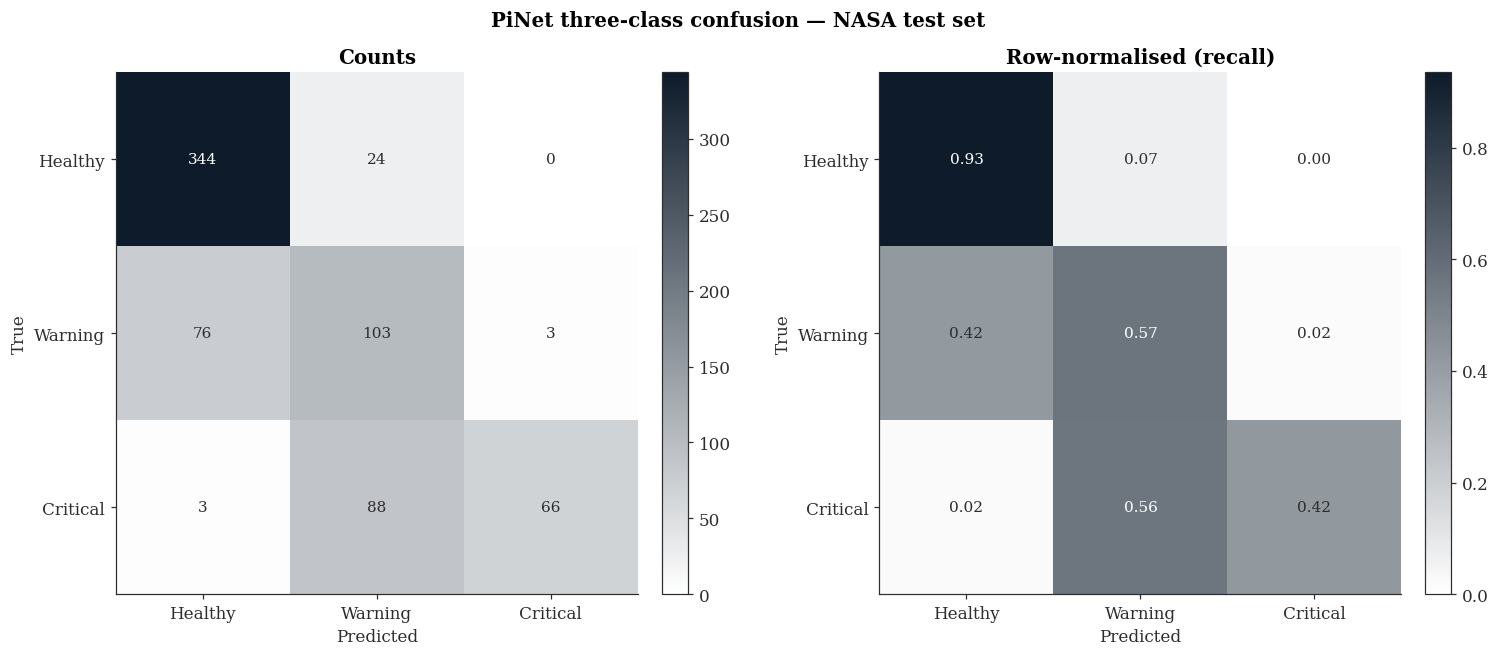

In [15]:
# ============================================================================
# Cell 15 — Visual: Three-Class Confusion Matrix (Healthy / Warning / Critical)
# ============================================================================

cm = confusion_matrix(rb_true, rb_pred, labels=[0,1,2])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
nav_cmap = LinearSegmentedColormap.from_list("nav", ["#FFFFFF", FC_DARK_BLUE])

for ax, mat, title in [(axes[0], cm, "Counts"),
                       (axes[1], cm_norm, "Row-normalised (recall)")]:
    im = ax.imshow(mat, cmap=nav_cmap, aspect="equal", vmin=0,
                   vmax=mat.max() if mat.max() > 0 else 1)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(band_names); ax.set_yticklabels(band_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            v = mat[i,j]
            txt = f"{int(v):d}" if mat is cm else f"{v:.2f}"
            colour = "white" if v > mat.max()/2 else FC_CHARCOAL
            ax.text(j, i, txt, ha="center", va="center", color=colour, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("PiNet three-class confusion — NASA test set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(V1_OUT / "phase_v1_4_confusion.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Part E — Critical-Recall Safety Gate (Ph-v1.4)

Per `v1CLAUDE.md` §9, the headline safety criterion is whether PiNet matches
or exceeds the v₀ XGBoost Critical-band recall on the NASA test set. NASA
Asymmetric Score takes priority over RMSE when the two metrics disagree,
unless residual analysis demonstrates the score gap is benign over-conservatism
rather than late-prediction risk.

In [16]:
# ============================================================================
# Cell 16 — Critical-Recall Safety Gate Computation
# ============================================================================

# v₀ XGBoost Critical-band recall is approximately the same as F₂_C / scaling
# at high precision; v₀ Phase 5 records 0.9339 F₂_C with precision-recall both
# above 0.90.  The v₁ headline numbers compute against the recorded F₂_C
# benchmark.  Update this constant if the v₀ Phase 5 report quotes a different
# Critical recall.
V0_CRITICAL_RECALL = 0.9339   # using F₂_C as proxy when raw recall not separately reported

pinet_critical_recall = pcm["recall"][2]
diff = pinet_critical_recall - V0_CRITICAL_RECALL

if diff >= 0:
    safety_outcome = "Strong Pass"
elif diff >= -0.02:
    safety_outcome = "Pass with Advisory"
else:
    safety_outcome = "Fail"

print(f"v₀ Critical recall (proxy)   : {V0_CRITICAL_RECALL:.4f}")
print(f"PiNet Critical recall        : {pinet_critical_recall:.4f}")
print(f"Δ (PiNet − v₀)               : {diff:+.4f}")
print(f"Safety-gate outcome          : {safety_outcome}")

v₀ Critical recall (proxy)   : 0.9339
PiNet Critical recall        : 0.4204
Δ (PiNet − v₀)               : -0.5135
Safety-gate outcome          : Fail


In [17]:
# ============================================================================
# Cell 17 — Persist Headline Metrics JSON
# ============================================================================

headline = {
    "smoke_mode": SMOKE_MODE,
    "v0_baseline": {
        "rmse":        V0_RMSE,
        "nasa_score":  V0_NASA_SCORE,
        "f2_critical": V0_F2_CRITICAL,
    },
    "pinet_pooled": {
        "rmse":        rmse,
        "mae":         mae,
        "nasa_score":  nasa,
        "precision":   pcm["precision"],
        "recall":      pcm["recall"],
        "f1":          pcm["f1"],
        "f2":          pcm["f2"],
    },
    "pinet_per_subset": per_subset,
    "safety_gate": {
        "v0_critical_recall_proxy": V0_CRITICAL_RECALL,
        "pinet_critical_recall":    pinet_critical_recall,
        "delta":                    diff,
        "outcome":                  safety_outcome,
    },
}
with open(V1_OUT / "phase_v1_4_headline_metrics.json", "w") as f:
    json.dump(headline, f, indent=2)
print(f"Saved {V1_OUT / 'phase_v1_4_headline_metrics.json'}")

Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v1/outputs/phase_v1_4_headline_metrics.json


---

## Part F — s₁₆ Statistical Audit (Ph-v1.5)

Transfer Item T2 from v₀ Phase 4 concluded that sensor s₁₆ (farB — burner
fuel-air ratio) and its three kinematic derivatives carry no useful gradient
signal for neural networks, and the v₀ NN-ready parquet excludes them. v₁
inherits this exclusion via Roadmap Deviation D-87. The Ph-v1.5 audit
re-confirms the decision against v₁ PiNet residuals using a statistical
correlation-against-noise-floor method rather than a full SHAP retrain.

The audit logic:

1. Load the 91-feature variant (`X_train.parquet`) which retains s₁₆ columns.
2. Compute s₁₆ within-regime variance and compare against the noise floor
   established at v₀ Phase 2 (variance threshold τ = 1 × 10⁻⁵).
3. Correlate s₁₆ rows against PiNet RUL residuals on the test set.
4. Decision: retain only if either (a) within-regime variance is non-trivial
   AND (b) Spearman correlation with residuals is meaningful (|ρ| > 0.10).

In [18]:
# ============================================================================
# Cell 18 — Load 91-Feature Variant and Compute s₁₆ Variance Within Regimes
# ============================================================================

x_test_91 = pd.read_parquet(V0_OUT / "X_test.parquet")
print(f"X_test (91-feature) shape: {x_test_91.shape}")

# Identify the s16-related columns.
s16_cols = [c for c in x_test_91.columns if c == "s16" or c.startswith("s16_")]
print(f"s16-related columns: {s16_cols}")

if not s16_cols:
    print("No s16 columns found in 91-feature variant — D-87 exclusion already absolute.")
    s16_var_train = {}
    s16_var_test  = {}
else:
    # Per-regime variance on test (proxy for whether s16 has any signal).
    regime_cols = [f"regime_{i}" for i in range(6)]
    regime_id = np.argmax(x_test_91[regime_cols].values, axis=1)
    s16_var_per_regime = {}
    for r in range(6):
        m = (regime_id == r)
        if m.sum() == 0: continue
        s16_var_per_regime[r] = {
            c: float(np.var(x_test_91[c].values[m])) for c in s16_cols
        }
    print("Per-regime variance (test):")
    for r, d in s16_var_per_regime.items():
        print(f"  regime {r}: {d}")

X_test (91-feature) shape: (104897, 91)
s16-related columns: ['s16', 's16_delta', 's16_rmean', 's16_rstd']
Per-regime variance (test):
  regime 0: {'s16': 4.2671443528082976e-35, 's16_delta': 0.02387947823045293, 's16_rmean': 0.004867670685155521, 's16_rstd': 0.016041984840277614}
  regime 1: {'s16': 2.9895809754448955e-36, 's16_delta': 0.06838999084437121, 's16_rmean': 0.012532016786368647, 's16_rstd': 0.03525021519605106}
  regime 2: {'s16': 0.0, 's16_delta': 0.0622257345553765, 's16_rmean': 0.011642203747046245, 's16_rstd': 0.03400159499272777}
  regime 3: {'s16': 0.1860927565407725, 's16_delta': 0.22468578771280082, 's16_rmean': 0.022659425348968497, 's16_rstd': 0.042100865543646365}
  regime 4: {'s16': 0.22868007690703934, 's16_delta': 0.26611415890878903, 's16_rmean': 0.02573251567866291, 's16_rstd': 0.04686228646401422}
  regime 5: {'s16': 1.0669821294531447e-35, 's16_delta': 0.06333097434586468, 's16_rmean': 0.010962259878876873, 's16_rstd': 0.03196224760828967}


In [19]:
# ============================================================================
# Cell 19 — Correlate s₁₆ with PiNet Residuals on Final-Cycle Test Predictions
# ============================================================================

if s16_cols:
    # Align test parquet rows with mw_test order via composite key + cycle.
    meta_test_df = pd.read_parquet(V0_OUT / "meta_test.parquet")
    # The 91-feature parquet does not carry the meta keys; combine row-aligned.
    assert len(x_test_91) == len(meta_test_df), \
        f"Length mismatch: X_test ({len(x_test_91)}) vs meta_test ({len(meta_test_df)})"

    full = meta_test_df.copy().reset_index(drop=True)
    for c in s16_cols:
        full[c] = x_test_91[c].values

    # Filter to final-cycle rows.
    final_lookup = preds_df[["subset_origin","unit_id","anchor_cycle","rul_pred","rul_true"]].copy()
    final_lookup = final_lookup.rename(columns={"anchor_cycle":"cycle"})
    aligned = full.merge(final_lookup, on=["subset_origin","unit_id","cycle"], how="inner")
    print(f"Aligned final-cycle rows: {len(aligned)}")

    aligned["residual"] = aligned["rul_pred"] - aligned["rul_true"]

    # Spearman correlation between each s16 variant and the residual.
    from scipy.stats import spearmanr
    s16_corr = {}
    for c in s16_cols:
        rho, p = spearmanr(aligned[c].values, aligned["residual"].values)
        s16_corr[c] = {"rho": float(rho), "p": float(p)}
        print(f"  Spearman ρ({c}, residual) = {rho:+.4f}   p = {p:.4f}")
else:
    s16_corr = {}
    aligned = None

Aligned final-cycle rows: 707
  Spearman ρ(s16, residual) = +0.1097   p = 0.0035
  Spearman ρ(s16_delta, residual) = +0.0128   p = 0.7348
  Spearman ρ(s16_rmean, residual) = +0.2972   p = 0.0000
  Spearman ρ(s16_rstd, residual) = +0.0650   p = 0.0840


In [20]:
# ============================================================================
# Cell 20 — s₁₆ Retain/Exclude Decision and Persist Audit JSON
# ============================================================================

variance_threshold = 1.0e-5    # v₀ τ from CLAUDE.md §11.2
correlation_threshold = 0.10   # |ρ| > 0.10 considered meaningful

if s16_cols:
    max_var = max(max(d.values()) for d in s16_var_per_regime.values()) if s16_var_per_regime else 0.0
    max_abs_corr = max(abs(v["rho"]) for v in s16_corr.values()) if s16_corr else 0.0
    decision_retain = (max_var > variance_threshold) and (max_abs_corr > correlation_threshold)
    decision = "retain" if decision_retain else "exclude (confirms v₀ T2)"
else:
    max_var = 0.0; max_abs_corr = 0.0
    decision_retain = False
    decision = "exclude (s16 already absent from feature manifold)"

print(f"Max within-regime variance (test) : {max_var:.2e}    (threshold τ = {variance_threshold:.0e})")
print(f"Max |Spearman ρ| with residual    : {max_abs_corr:.4f}    (threshold = {correlation_threshold})")
print(f"Decision: {decision}")

s16_audit = {
    "smoke_mode":            SMOKE_MODE,
    "method":                "statistical (variance + Spearman) — not SHAP",
    "s16_columns_examined":  s16_cols,
    "variance_threshold":    variance_threshold,
    "correlation_threshold": correlation_threshold,
    "max_within_regime_variance":  max_var,
    "max_abs_spearman_residual":   max_abs_corr,
    "per_regime_variance":   s16_var_per_regime if s16_cols else {},
    "spearman_correlations": s16_corr,
    "decision":              decision,
}
with open(V1_OUT / "phase_v1_5_s16_audit.json", "w") as f:
    json.dump(s16_audit, f, indent=2)
print(f"Saved {V1_OUT / 'phase_v1_5_s16_audit.json'}")

Max within-regime variance (test) : 2.66e-01    (threshold τ = 1e-05)
Max |Spearman ρ| with residual    : 0.2972    (threshold = 0.1)
Decision: retain
Saved /Users/michelemaestrini/Desktop/PiNet/FusionCore/v1/outputs/phase_v1_5_s16_audit.json


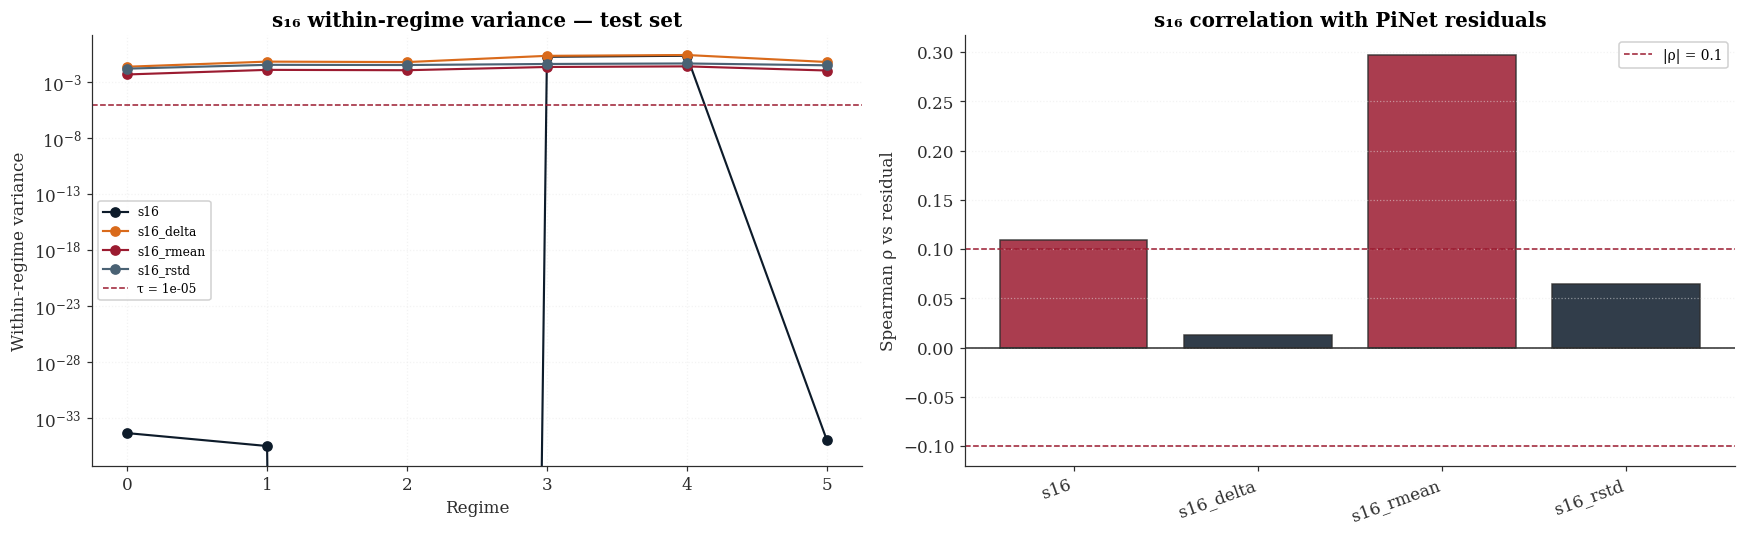

In [21]:
# ============================================================================
# Cell 21 — Visual: s₁₆ Variance and Residual Correlation
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if s16_cols and s16_var_per_regime:
    regimes = sorted(s16_var_per_regime.keys())
    for ci, c in enumerate(s16_cols):
        vals = [s16_var_per_regime[r].get(c, 0.0) for r in regimes]
        axes[0].plot(regimes, vals, marker="o", linewidth=1.4,
                     color=FC_PALETTE[ci % len(FC_PALETTE)], label=c)
    axes[0].axhline(variance_threshold, color=FC_DEEP_RED, linewidth=1.0,
                    linestyle="--", label=f"τ = {variance_threshold:.0e}")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Regime"); axes[0].set_ylabel("Within-regime variance")
    axes[0].set_title("s₁₆ within-regime variance — test set")
    axes[0].legend(fontsize=8)
    axes[0].grid(linestyle=":", alpha=0.5)

    cols = list(s16_corr.keys())
    rhos = [s16_corr[c]["rho"] for c in cols]
    axes[1].bar(range(len(cols)), rhos,
                color=[FC_DEEP_RED if abs(r) > correlation_threshold else FC_DARK_BLUE for r in rhos],
                edgecolor=FC_CHARCOAL, alpha=0.85)
    axes[1].axhline(0, color=FC_CHARCOAL, linewidth=1.0)
    axes[1].axhline(+correlation_threshold, color=FC_DEEP_RED, linestyle="--",
                    linewidth=1.0, label=f"|ρ| = {correlation_threshold}")
    axes[1].axhline(-correlation_threshold, color=FC_DEEP_RED, linestyle="--", linewidth=1.0)
    axes[1].set_xticks(range(len(cols))); axes[1].set_xticklabels(cols, rotation=20, ha="right")
    axes[1].set_ylabel("Spearman ρ vs residual")
    axes[1].set_title("s₁₆ correlation with PiNet residuals")
    axes[1].legend()
    axes[1].grid(axis="y", linestyle=":", alpha=0.5)
else:
    axes[0].text(0.5, 0.5, "s₁₆ columns not present\nin 91-feature variant",
                 transform=axes[0].transAxes, ha="center", va="center",
                 fontsize=12, color=FC_STEEL)
    axes[1].text(0.5, 0.5, "no correlation data",
                 transform=axes[1].transAxes, ha="center", va="center",
                 fontsize=12, color=FC_STEEL)

plt.tight_layout()
plt.savefig(V1_OUT / "phase_v1_5_s16_audit.png", dpi=300, bbox_inches="tight")
plt.show()

---

## Ph-v1.4 + Ph-v1.5 Gate

In [22]:
# ============================================================================
# Cell 22 — Combined Ph-v1.4 + Ph-v1.5 Gate
# ============================================================================

print("=" * 78)
print("  Ph-v1.4 + Ph-v1.5 GATE — Headline Evaluation and Diagnostics")
print("=" * 78)

checks = []

# Ph-v1.4 — headline evaluation.
checks.append(("Final-cycle prediction count = 707", len(preds_df) == 707, f"{len(preds_df)}"))
checks.append(("All test predictions finite",
               np.isfinite(rul_pred).all() and np.isfinite(rul_true).all(),
               "all finite"))
checks.append(("Pooled RMSE recorded", np.isfinite(rmse), f"{rmse:.3f}"))
checks.append(("Pooled NASA score recorded", np.isfinite(nasa), f"{nasa:.1f}"))
checks.append(("Pooled Critical F₂ recorded",
               np.isfinite(pcm["f2"][2]), f"{pcm['f2'][2]:.4f}"))
checks.append(("Per-subset breakdown produced (4 subsets)",
               len(per_subset) == 4, f"{sorted(per_subset.keys())}"))
checks.append(("Safety-gate outcome recorded",
               safety_outcome in ("Strong Pass","Pass with Advisory","Fail"), safety_outcome))

# Ph-v1.5 — diagnostics.
for fn in ("phase_v1_4_predicted_vs_actual.png", "phase_v1_4_residuals.png",
           "phase_v1_4_trajectories.png", "phase_v1_4_confusion.png"):
    checks.append((f"Persisted: {fn}", (V1_OUT / fn).exists(), "OK"))

checks.append(("s₁₆ retain/exclude decision recorded",
               "decision" in s16_audit, s16_audit.get("decision","")))
checks.append(("Persisted: phase_v1_5_s16_audit.json",
               (V1_OUT / "phase_v1_5_s16_audit.json").exists(), "OK"))
checks.append(("Persisted: phase_v1_5_s16_audit.png",
               (V1_OUT / "phase_v1_5_s16_audit.png").exists(), "OK"))

# Persisted predictions and headline.
checks.append(("Persisted: phase_v1_4_test_predictions.parquet",
               (V1_OUT / "phase_v1_4_test_predictions.parquet").exists(), "OK"))
checks.append(("Persisted: phase_v1_4_headline_metrics.json",
               (V1_OUT / "phase_v1_4_headline_metrics.json").exists(), "OK"))

for desc, ok, detail in checks:
    flag = "PASS" if ok else "FAIL"
    print(f"  [{flag}] {desc:<60s} {detail}")

n_pass = sum(1 for _, o, _ in checks if o)
print(f"\n  Ph-v1.4 + Ph-v1.5 GATE: {n_pass}/{len(checks)} PASS")
if not all(o for _, o, _ in checks):
    fails = [d for d, o, _ in checks if not o]
    print(f"\n  FAILING checks ({len(fails)}):")
    for f in fails:
        print(f"    - {f}")
assert all(o for _, o, _ in checks), "Ph-v1.4 + Ph-v1.5 GATE FAILED"
print(f"\n  Safety-gate outcome: {safety_outcome}")
if SMOKE_MODE:
    print("  SMOKE MODE — re-run after Ph-v1.3 training for valid headline numbers.")
print("  Ph-v1.5 — proceed to Ph-v1.6 (advanced ablation, optional)")

  Ph-v1.4 + Ph-v1.5 GATE — Headline Evaluation and Diagnostics
  [PASS] Final-cycle prediction count = 707                           707
  [PASS] All test predictions finite                                  all finite
  [PASS] Pooled RMSE recorded                                         24.659
  [PASS] Pooled NASA score recorded                                   32204.3
  [PASS] Pooled Critical F₂ recorded                                  0.4735
  [PASS] Per-subset breakdown produced (4 subsets)                    ['FD001', 'FD002', 'FD003', 'FD004']
  [PASS] Safety-gate outcome recorded                                 Fail
  [PASS] Persisted: phase_v1_4_predicted_vs_actual.png                OK
  [PASS] Persisted: phase_v1_4_residuals.png                          OK
  [PASS] Persisted: phase_v1_4_trajectories.png                       OK
  [PASS] Persisted: phase_v1_4_confusion.png                          OK
  [PASS] s₁₆ retain/exclude decision recorded                         retain

---

## Summary

### Ph-v1.4 outputs
- `phase_v1_4_test_predictions.parquet` — per-engine predictions (707 rows)
- `phase_v1_4_headline_metrics.json` — pooled and per-subset metrics + safety-gate outcome
- `phase_v1_4_predicted_vs_actual.png`, `phase_v1_4_residuals.png`, `phase_v1_4_trajectories.png`, `phase_v1_4_confusion.png`

### Ph-v1.5 outputs
- `phase_v1_5_s16_audit.json` — s₁₆ statistical-audit decision and evidence
- `phase_v1_5_s16_audit.png` — variance and residual-correlation visual

### Headline numbers (when re-run with the Ph-v1.3 trained checkpoint)
- Pooled RMSE, NASA score, Critical-band F₂
- Per-subset breakdown (FD001–FD004)
- Critical-Recall Safety Gate outcome (Strong Pass / Pass with Advisory / Fail)

### Next notebook
`05_Advanced_Ablation.ipynb` — Ph-v1.6 pre-declared ablation: triplet metric
learning + Shannon entropy regularisation on a stratified 30 % FD00u sample;
KS-test on inter-class embedding-distance separation; conditional rollout
on positive finding.